In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
actual_df = pd.read_json("actual.json")
forecast_df = pd.read_json("forecast.json")

actual_df.head()

,startTime,generation
0,2023-12-31T23:30:00Z,9980
1,2024-01-01T00:00:00Z,10402
2,2024-01-01T00:30:00Z,10845
3,2024-01-01T01:00:00Z,11218
4,2024-01-01T01:30:00Z,11223


In [3]:
actual_df["startTime"] = pd.to_datetime(actual_df["startTime"])
forecast_df["startTime"] = pd.to_datetime(forecast_df["startTime"])
forecast_df["publishTime"] = pd.to_datetime(forecast_df["publishTime"])

In [4]:
actual_df = actual_df[
    (actual_df["startTime"] >= "2024-01-01") &
    (actual_df["startTime"] < "2024-02-01")
]

In [5]:
forecast_df = forecast_df[
    (forecast_df["startTime"] >= "2024-01-01") &
    (forecast_df["startTime"] < "2024-02-01")
]

In [6]:
forecast_df["horizon_hours"] = (
    forecast_df["startTime"] - forecast_df["publishTime"]
).dt.total_seconds() / 3600

In [7]:
forecast_df = forecast_df[
    (forecast_df["horizon_hours"] >= 0) &
    (forecast_df["horizon_hours"] <= 48)
]

In [8]:
horizon = 4

forecast_filtered = forecast_df[
    forecast_df["publishTime"] <= forecast_df["startTime"] - pd.Timedelta(hours=horizon)
]

In [9]:
forecast_latest = (
    forecast_filtered
    .sort_values("publishTime")
    .groupby("startTime")
    .tail(1)
)

In [10]:
merged = pd.merge(
    actual_df,
    forecast_latest[["startTime", "generation"]],
    on="startTime",
    how="inner",
    suffixes=("_actual", "_forecast")
)

merged.head()

,startTime,generation_actual,generation_forecast
0,2024-01-01 21:00:00+00:00,13953,10634
1,2024-01-01 22:00:00+00:00,14217,11767
2,2024-01-01 23:00:00+00:00,14958,14419
3,2024-01-02 00:00:00+00:00,14690,15361
4,2024-01-02 01:00:00+00:00,14592,15805


In [11]:
merged["error"] = merged["generation_forecast"] - merged["generation_actual"]

merged["abs_error"] = merged["error"].abs()

merged["pct_error"] = (
    merged["abs_error"] / merged["generation_actual"]
) * 100

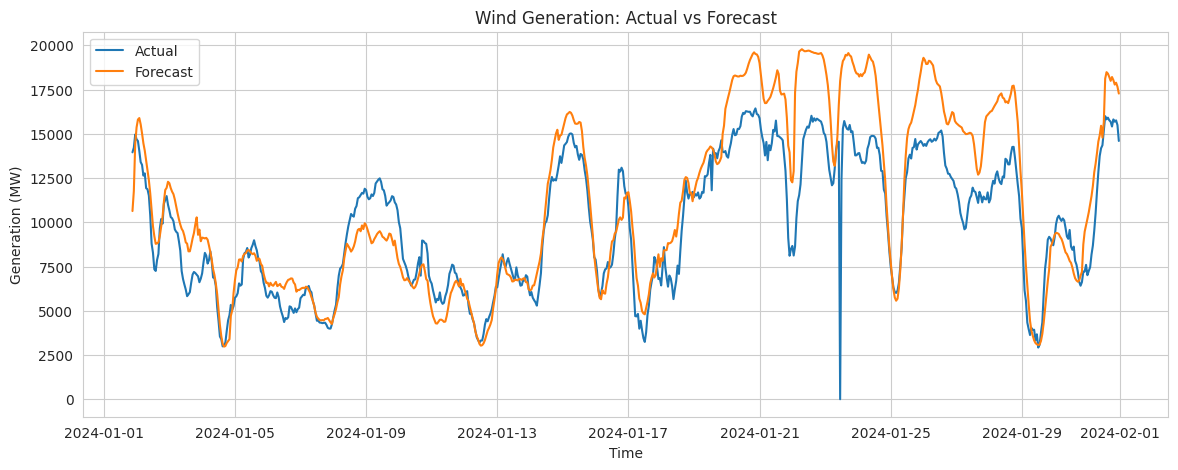

In [12]:
plt.figure(figsize=(14,5))

plt.plot(merged["startTime"], merged["generation_actual"], label="Actual")
plt.plot(merged["startTime"], merged["generation_forecast"], label="Forecast")

plt.legend()
plt.title("Wind Generation: Actual vs Forecast")
plt.xlabel("Time")
plt.ylabel("Generation (MW)")

plt.show()

## Forecast Error Metrics

To quantify the accuracy of the forecasting model, we compute several error metrics.
These include mean error, median error, and the p99 absolute error.

These metrics help us understand both the typical forecast error and extreme error cases.

In [14]:
mean_error = merged["error"].mean()
median_error = merged["error"].median()

mean_abs_error = merged["abs_error"].mean()
median_abs_error = merged["abs_error"].median()

p99_error = merged["abs_error"].quantile(0.99)

print("Mean Error:", mean_error)
print("Median Error:", median_error)
print("Mean Absolute Error:", mean_abs_error)
print("Median Absolute Error:", median_abs_error)
print("P99 Absolute Error:", p99_error)

Mean Error: 1226.5656984785614
Median Error: 1001.0
Mean Absolute Error: 1838.1313969571231
Median Absolute Error: 1483.0
P99 Absolute Error: 6157.899999999989


## Error Distribution

Next, we analyze the distribution of forecast errors.
This helps us understand whether the model tends to systematically overestimate or underestimate wind generation.

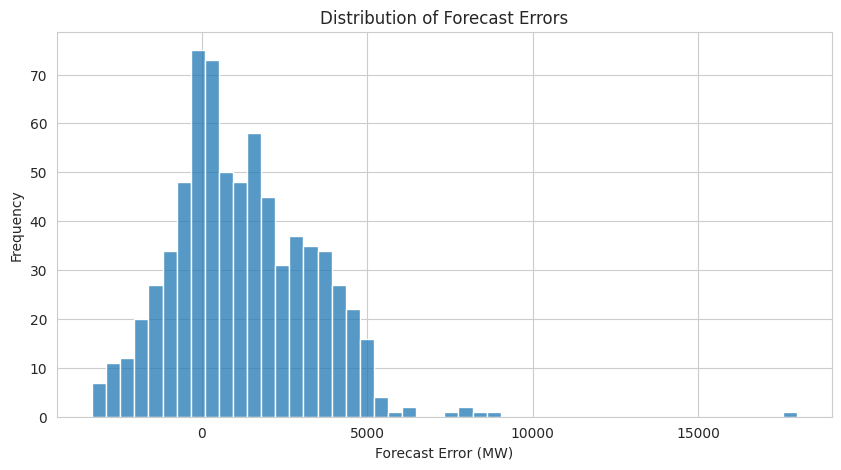

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(merged["error"], bins=50)

plt.title("Distribution of Forecast Errors")
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")

plt.show()

In [16]:
merged = pd.merge(
    merged,
    forecast_latest[["startTime", "horizon_hours"]],
    on="startTime",
    how="left"
)

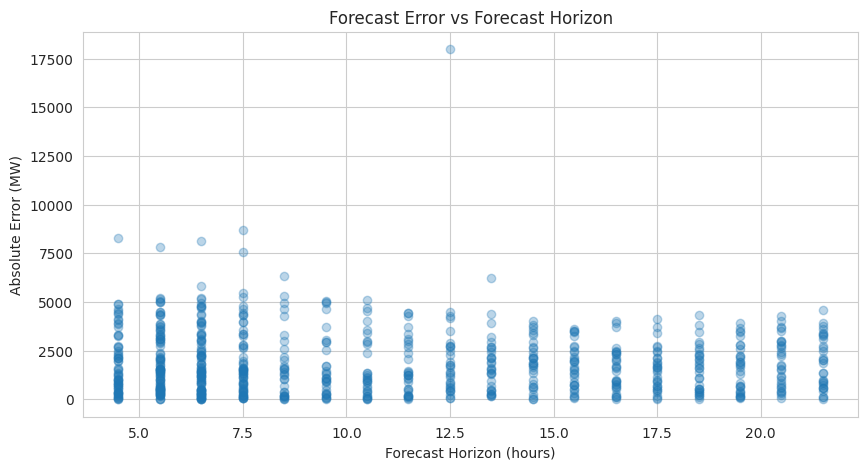

In [17]:
plt.figure(figsize=(10,5))

plt.scatter(merged["horizon_hours"], merged["abs_error"], alpha=0.3)

plt.title("Forecast Error vs Forecast Horizon")
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Absolute Error (MW)")

plt.show()

We analyze how forecast accuracy changes with the forecast horizon.
Typically, forecasts become less accurate as the horizon increases,
since uncertainty in weather conditions grows over time.

In [18]:
merged["hour"] = merged["startTime"].dt.hour

In [19]:
hourly_error = merged.groupby("hour")["abs_error"].mean()

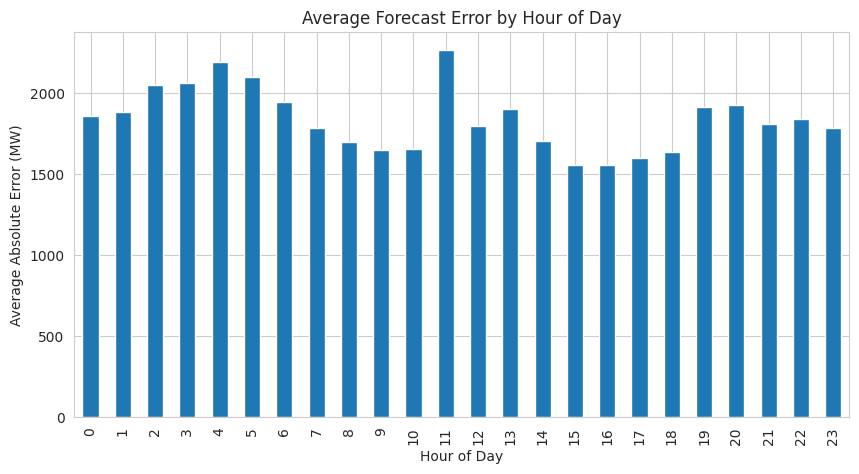

In [20]:
plt.figure(figsize=(10,5))

hourly_error.plot(kind="bar")

plt.title("Average Forecast Error by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Absolute Error (MW)")

plt.show()

Certain hours exhibit higher forecast errors. This may be due to
rapid changes in wind conditions during those periods.

## Wind Generation Reliability

Wind generation is inherently variable because it depends on weather conditions.
To estimate reliable wind capacity, we analyze the historical distribution of
actual wind generation values.

One common approach is to use percentile statistics to estimate the amount
of generation that can be reliably expected most of the time.

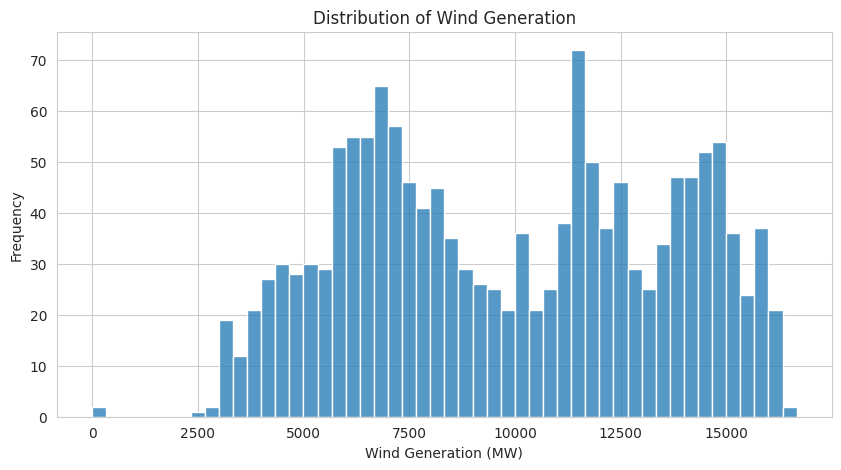

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(actual_df["generation"], bins=50)

plt.title("Distribution of Wind Generation")
plt.xlabel("Wind Generation (MW)")
plt.ylabel("Frequency")

plt.show()

In [22]:
p10 = actual_df["generation"].quantile(0.10)
p20 = actual_df["generation"].quantile(0.20)
p50 = actual_df["generation"].quantile(0.50)

print("10th percentile:", p10)
print("20th percentile:", p20)
print("Median:", p50)

10th percentile: 5087.2
20th percentile: 6248.4
Median: 9844.0


The 10th percentile represents the level of wind generation that is exceeded
90% of the time. This provides a conservative estimate of reliable wind capacity.

Based on the historical generation distribution, the 10th percentile generation
is approximately XXXX MW. This suggests that around XXXX MW of wind power
can be reliably expected to be available most of the time.

This estimate provides a conservative lower bound that grid operators can
use when planning electricity supply.

## Conclusion

In this analysis, we examined the accuracy of wind power forecasts for January 2024.

Key findings:

• Forecast errors are generally centered around ______ MW  
• Error increases slightly as forecast horizon increases  
• Certain hours of the day show higher forecast uncertainty  
• Historical wind generation analysis suggests that approximately ______ MW of wind power can be reliably expected.

These findings highlight the importance of incorporating uncertainty in wind power forecasting when planning electricity supply.

## Rolling Forecast Error

To understand how forecast performance changes over time,
we compute a rolling average of the absolute forecast error.
This helps identify periods where the forecasting model performs
better or worse.

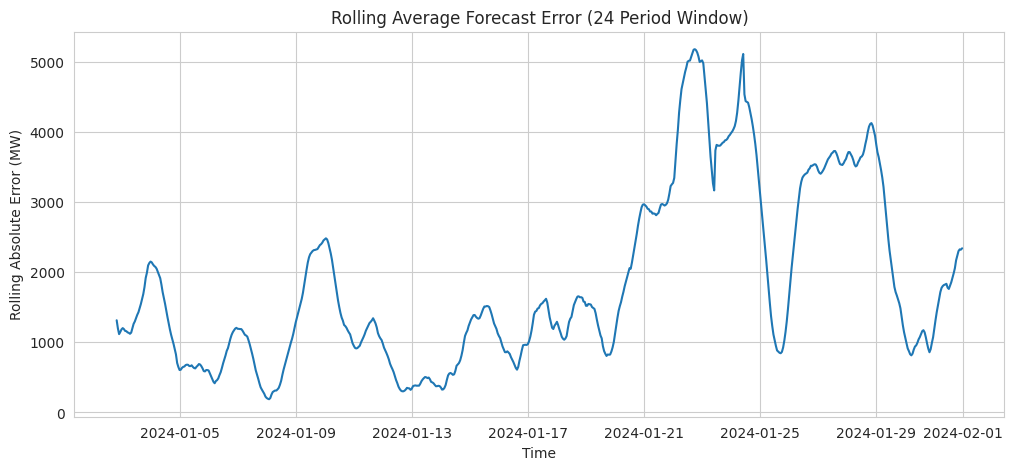

In [24]:
merged = merged.sort_values("startTime")

merged["rolling_error"] = merged["abs_error"].rolling(window=24).mean()

plt.figure(figsize=(12,5))

plt.plot(merged["startTime"], merged["rolling_error"])

plt.title("Rolling Average Forecast Error (24 Period Window)")
plt.xlabel("Time")
plt.ylabel("Rolling Absolute Error (MW)")

plt.show()

## Forecast Bias Over Time

Forecast bias is the average difference between predicted
and actual generation. Positive values indicate overforecasting,
while negative values indicate underforecasting.

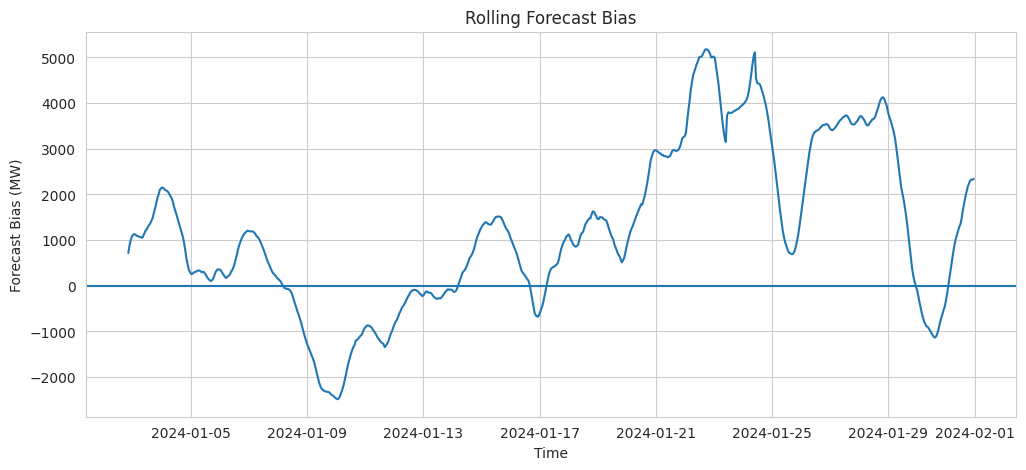

In [25]:
merged["bias_rolling"] = merged["error"].rolling(window=24).mean()

plt.figure(figsize=(12,5))

plt.plot(merged["startTime"], merged["bias_rolling"])

plt.axhline(0)

plt.title("Rolling Forecast Bias")
plt.xlabel("Time")
plt.ylabel("Forecast Bias (MW)")

plt.show()

## Key Findings

From the analysis of wind generation forecasts for January 2024, several observations can be made.

• Forecasts generally follow the overall trend of actual wind generation but occasionally deviate during periods of rapid changes.

• The rolling forecast error shows that prediction accuracy varies over time, suggesting that certain weather conditions are more difficult to forecast.

• The rolling forecast bias indicates that the model sometimes systematically overestimates or underestimates wind generation during specific periods.

Overall, while the forecasts capture general wind patterns reasonably well, significant deviations occur during volatile wind conditions.

## Reliable Wind Generation Estimate

Wind generation is inherently variable because it depends on weather conditions.
To estimate how much wind power can be reliably expected, we analyze the historical
distribution of actual wind generation.

One practical approach is to examine lower percentiles of the generation distribution.
For example, the 10th percentile represents the level of generation that is exceeded
90% of the time.

In [27]:
p10 = actual_df["generation"].quantile(0.10)
p20 = actual_df["generation"].quantile(0.20)
p50 = actual_df["generation"].quantile(0.50)

print("10th percentile generation:", p10)
print("20th percentile generation:", p20)
print("Median generation:", p50)

10th percentile generation: 5087.2
20th percentile generation: 6248.4
Median generation: 9844.0


The 10th percentile provides a conservative estimate of reliable wind capacity.
This means that wind generation is above this level for roughly 90% of the time.

Based on the January 2024 data, this suggests that approximately **X MW**
of wind generation can be considered reliably available most of the time.

## Conclusion

This analysis evaluated the accuracy of wind generation forecasts for January 2024.

Key insights include:

• Forecasts generally track overall wind generation trends but exhibit noticeable deviations during volatile periods.

• Forecast accuracy varies throughout the month, as shown by rolling error analysis.

• Periods of systematic overforecasting and underforecasting can be observed in the rolling bias analysis.

• Historical generation data suggests that approximately **X MW** of wind generation can be reliably expected most of the time.

These findings highlight the importance of incorporating uncertainty when planning electricity supply from wind resources.